<a href="https://colab.research.google.com/github/sramalhao/strawhat-analytics/blob/main/OnePieceArcs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

sns.set_theme(style="whitegrid")

In [2]:
data = pd.read_csv('/content/OnePieceArcs.csv')
data.head()

,Arc,Start onChapter,TotalChapters,TotalPages,Manga%,Start onEpisode,TotalEpisodes,TotalMinutes(avg 24),Anime%
0,Romance Dawn Arc,1,7,178,0.9%,1,3,72,0.3%
1,Orange Town Arc,8,14,273,1.4%,4,5,120,0.5%
2,Syrup Village Arc,22,20,396,2.0%,9,10,240,1.0%
3,Baratie Arc,42,27,514,2.6%,19,12,288,1.2%
4,Arlong Park Arc,69,27,514,2.6%,31,15,360,1.5%


In [5]:
# Data cleaning and standartization
data['Manga_Percent'] = data['Manga%'].str.replace('%', '').astype(float)
data['Anime_Percent'] = data['Anime%'].str.replace('%', '').astype(float)

## 1. Filler Analysis (Original Anime Content)

Let’s find out how much time the series spends on TV-exclusive storylines that are not present in the manga.


In [6]:
fillers = data[data['TotalChapters']==0]

In [8]:
total_filler_episodes = fillers['TotalEpisodes'].sum()
total_filler_minutes = fillers['TotalMinutes(avg 24)'].sum()
filler_hours = total_filler_minutes / 60

print(f"Total filler episodes detected: {total_filler_episodes} episodes.")
print(f"Total time spent watching fillers: {total_filler_minutes} minutes (or {filler_hours:.1f} hours).")

print("\n--- Largest Filler Arcs ---")
# Listing the top 5 largest filler arcs by number of episodes
top_fillers = fillers.sort_values(by='TotalEpisodes', ascending=False)[['Arc', 'TotalEpisodes', 'TotalMinutes(avg 24)']]
display(top_fillers.head())

Total filler episodes detected: 79 episodes.
Total time spent watching fillers: 1896 minutes (or 31.6 hours).

--- Largest Filler Arcs ---


,Arc,TotalEpisodes,TotalMinutes(avg 24)
19,G-8 Arc,11,264
26,Ice Hunter Arc,11,264
7,Warship Island Arc,8,192
21,Ocean's Dream Arc,5,120
14,Post-Alabasta Arc,5,120


## 2. Adaptation Pacing: Manga vs. Anime

How many manga chapters are adapted on average per anime episode? The `Chapters per Episode` calculation will help us understand the pacing of the series (excluding fillers).

In [10]:
# Isolating only canonical content (present in the manga)
canon = data[data['TotalChapters'] > 0].copy()

# Calculating pacing: Chapters divided by Episodes
canon['Pacing (Chapters/Episode)'] = canon['TotalChapters'] / canon['TotalEpisodes']

print("--- FASTEST arcs (adapt more chapters per episode) ---")
display(
    canon.sort_values(by='Pacing (Chapters/Episode)', ascending=False)[
        ['Arc', 'TotalChapters', 'TotalEpisodes', 'Pacing (Chapters/Episode)']
    ].head()
)

print("\n--- SLOWEST arcs (stretch few chapters across many episodes) ---")
display(
    canon.sort_values(by='Pacing (Chapters/Episode)', ascending=True)[
        ['Arc', 'TotalChapters', 'TotalEpisodes', 'Pacing (Chapters/Episode)']
    ].head()
)

--- FASTEST arcs (adapt more chapters per episode) ---


,Arc,TotalChapters,TotalEpisodes,Pacing (Chapters/Episode)
1,Orange Town Arc,14,5,2.800000
8,Reverse Mountain Arc,5,2,2.500000
0,Romance Dawn Arc,7,3,2.333333
9,Whiskey Peak Arc,9,4,2.250000
3,Baratie Arc,27,12,2.250000



--- SLOWEST arcs (stretch few chapters across many episodes) ---


,Arc,TotalChapters,TotalEpisodes,Pacing (Chapters/Episode)
46,Levely Arc,6,12,0.500000
47,Wano Country Arc: Act 1,16,26,0.615385
35,Post-War Arc,17,27,0.629630
31,Amazon Lily Arc,11,14,0.785714
43,Zou Arc,23,29,0.793103


## 3. The Largest Arcs in the Series

Which arcs are the most massive in terms of episode count and binge-watching time?

--- Top 5 Largest Arcs (by Anime Episodes) ---


,Arc,TotalEpisodes,TotalChapters,TotalMinutes(avg 24)
41,Dressrosa Arc,118,102,2832
45,Whole Cake Island Arc,95,78,2280
50,Wano Country Arc: Act 3,70,99,1680
37,Fishman Island Arc,52,51,1248
24,Enies Lobby Arc,49,56,1176


/tmp/ipykernel_10804/2266246246.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalEpisodes', y='Arc', data=largest_arcs, palette='viridis')


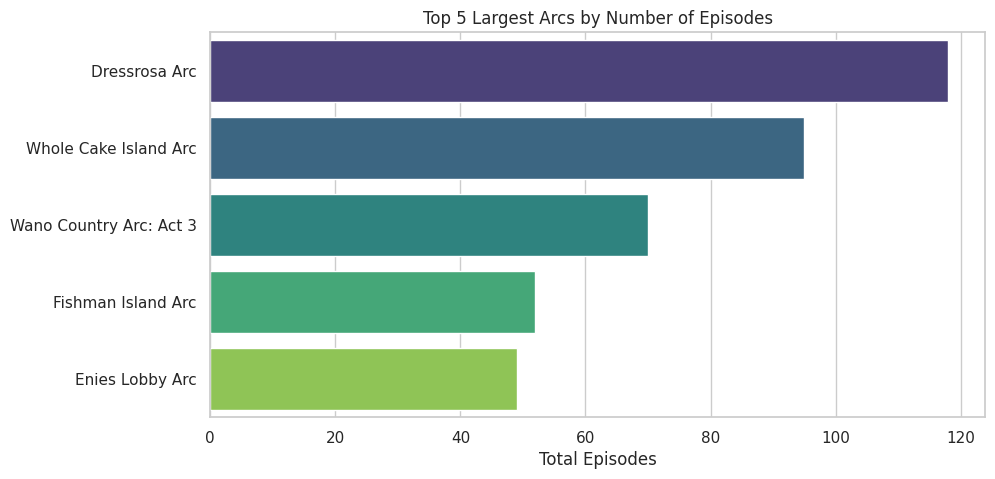

In [13]:
# Sorting the data by arcs with the highest number of episodes and displaying the Top 5
largest_arcs = data.sort_values(by='TotalEpisodes', ascending=False)[
    ['Arc', 'TotalEpisodes', 'TotalChapters', 'TotalMinutes(avg 24)']
].head(5)

print("--- Top 5 Largest Arcs (by Anime Episodes) ---")
display(largest_arcs)

# Visualization of the Largest Arcs in the Anime
plt.figure(figsize=(10, 5))
sns.barplot(x='TotalEpisodes', y='Arc', data=largest_arcs, palette='viridis')
plt.title('Top 5 Largest Arcs by Number of Episodes')
plt.xlabel('Total Episodes')
plt.ylabel('')
plt.show()

## 4. Pacing Evolution Over Time

Has the anime been getting slower over the years? Let’s plot a timeline showing the pacing of canonical arcs as the story progresses (using each arc’s starting episode as the timeline reference).

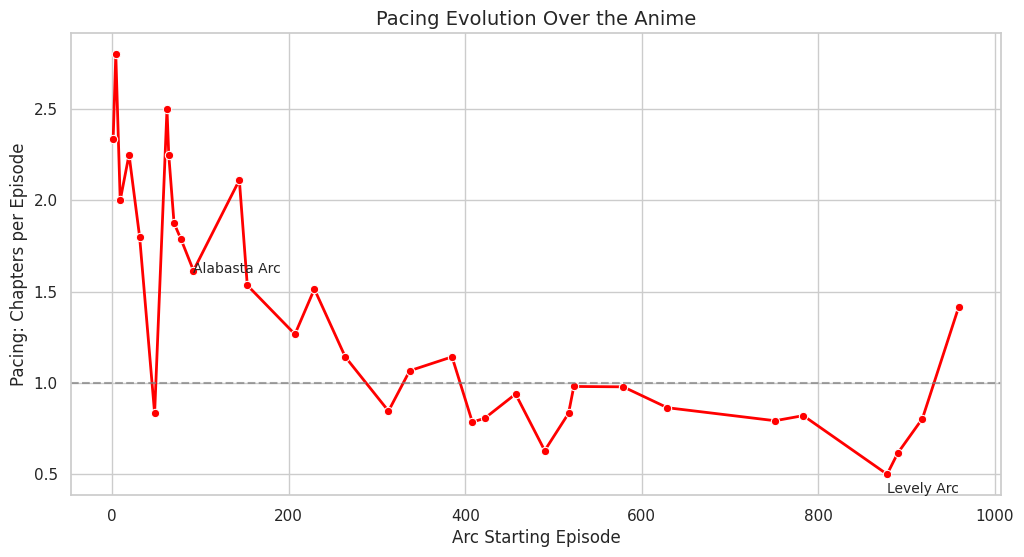

In [15]:
plt.figure(figsize=(12, 6))
# Plotting the pacing evolution (Chapters/Episode) by Arc Start Episode
sns.lineplot(
    x='Start onEpisode',
    y='Pacing (Chapters/Episode)',
    data=canon,
    marker='o',
    color='red',
    linewidth=2
)

plt.axhline(1.0, ls='--', color='gray', alpha=0.7)  # Reference line: 1 Chapter = 1 Episode
plt.title('Pacing Evolution Over the Anime', fontsize=14)
plt.xlabel('Arc Starting Episode')
plt.ylabel('Pacing: Chapters per Episode')

# Adding annotations to highlight specific points
# Alabasta started at episode 92 and Levely at 878
plt.text(92, 1.6, 'Alabasta Arc', fontsize=10)
plt.text(878, 0.4, 'Levely Arc', fontsize=10)

plt.show()

## 5. Story Proportion: Which Arcs Get More Spotlight on TV?

Finally, let’s calculate the percentage discrepancy between how much each arc occupies in the manga versus how much it takes up on TV. Arcs with positive differences underwent significant “expansion” when adapted into the anime.

--- Arcs That Expanded the Most in the Anime ---


,Arc,Manga_Percent,Anime_Percent,Expansion_in_Anime (%)
45,Whole Cake Island Arc,6.9,9.2,2.3
41,Dressrosa Arc,9.4,11.5,2.1
49,Wano Country Arc: Act 2,2.9,4.0,1.1
47,Wano Country Arc: Act 1,1.4,2.5,1.1
35,Post-War Arc,1.6,2.6,1.0


/tmp/ipykernel_10804/2325357736.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Expansion_in_Anime (%)', y='Arc', data=most_expanded, palette='magma')


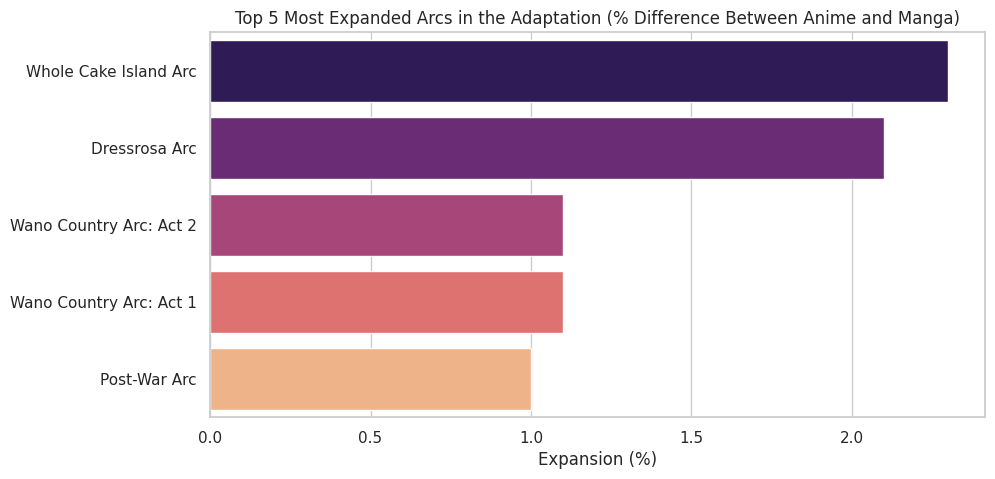

In [16]:
# Percentage difference = how much it represents in the Anime minus how much it represents in the Manga
canon['Expansion_in_Anime (%)'] = canon['Anime_Percent'] - canon['Manga_Percent']

# Selecting the top 5 arcs that grew the most in proportion from manga to anime
most_expanded = canon.sort_values(by='Expansion_in_Anime (%)', ascending=False)[
    ['Arc', 'Manga_Percent', 'Anime_Percent', 'Expansion_in_Anime (%)']
].head(5)

print("--- Arcs That Expanded the Most in the Anime ---")
display(most_expanded)

# Plot of percentage expansion
plt.figure(figsize=(10, 5))
sns.barplot(x='Expansion_in_Anime (%)', y='Arc', data=most_expanded, palette='magma')
plt.title('Top 5 Most Expanded Arcs in the Adaptation (% Difference Between Anime and Manga)')
plt.xlabel('Expansion (%)')
plt.ylabel('')
plt.show()

## 6. Manga Density: Pages per Chapter

Has Eiichiro Oda been drawing shorter or longer chapters over the years? The dataset provides the total number of chapters and pages for each arc. We can determine the density of each arc by dividing TotalPages by TotalChapters.

--- Arcs with the Longest Chapters (Highest number of pages) ---


,Arc,TotalChapters,TotalPages,Pages_per_Chapter
0,Romance Dawn Arc,7,178,25.428571
6,Loguetown Arc,5,100,20.000000
2,Syrup Village Arc,20,396,19.800000
36,Return to Sabaody Arc,5,98,19.600000
1,Orange Town Arc,14,273,19.500000



--- Arcs with the Shortest Chapters (Lowest number of pages) ---


,Arc,TotalChapters,TotalPages,Pages_per_Chapter
46,Levely Arc,6,100,16.666667
49,Wano Country Arc: Act 2,33,560,16.969697
34,Marineford Arc,31,529,17.064516
43,Zou Arc,23,397,17.260870
50,Wano Country Arc: Act 3,99,1709,17.262626


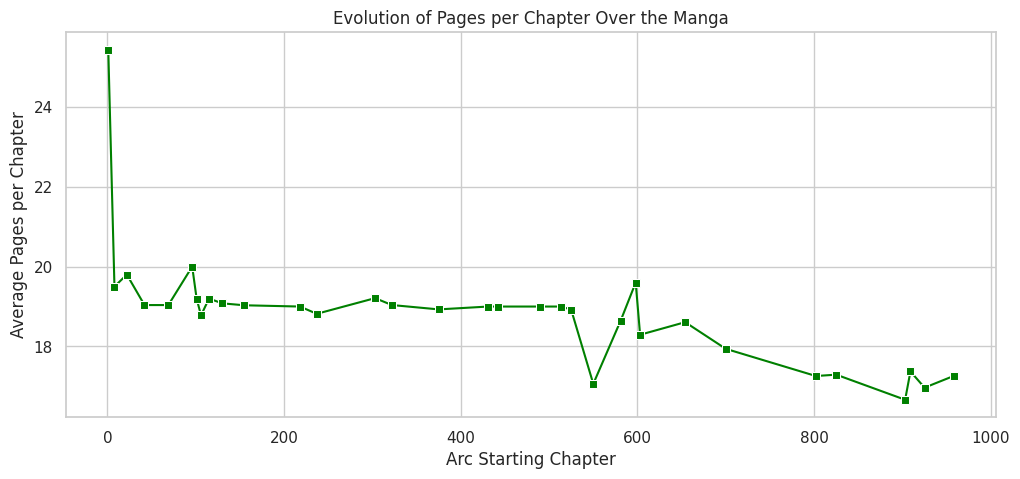

In [17]:
# Isolating only canonical content (ignoring fillers where TotalChapters is 0)
canon = data[data['TotalChapters'] > 0].copy()

# Calculating the average number of pages per chapter
canon['Pages_per_Chapter'] = canon['TotalPages'] / canon['TotalChapters']

print("--- Arcs with the Longest Chapters (Highest number of pages) ---")
display(
    canon.sort_values(by='Pages_per_Chapter', ascending=False)[
        ['Arc', 'TotalChapters', 'TotalPages', 'Pages_per_Chapter']
    ].head(5)
)

print("\n--- Arcs with the Shortest Chapters (Lowest number of pages) ---")
display(
    canon.sort_values(by='Pages_per_Chapter', ascending=True)[
        ['Arc', 'TotalChapters', 'TotalPages', 'Pages_per_Chapter']
    ].head(5)
)

# Visualization of the trend over time
plt.figure(figsize=(12, 5))
sns.lineplot(x='Start onChapter', y='Pages_per_Chapter', data=canon, marker='s', color='green')
plt.title('Evolution of Pages per Chapter Over the Manga')
plt.xlabel('Arc Starting Chapter')
plt.ylabel('Average Pages per Chapter')
plt.show()

## 7. Anime “Stretching” Level: Minutes per Manga Page

Classic pacing compares Chapters per Episode, but chapters vary in length. A much more precise metric to measure how much the anime “stretches” scenes is calculating how many screen minutes are used to adapt a single manga page.

--- Most Stretched Arcs (More screen time per manga page) ---


,Arc,TotalMinutes(avg 24),TotalPages,Minutes_per_Page
46,Levely Arc,288,100,2.880000
47,Wano Country Arc: Act 1,624,278,2.244604
35,Post-War Arc,648,317,2.044164
49,Wano Country Arc: Act 2,984,560,1.757143
43,Zou Arc,696,397,1.753149


/tmp/ipykernel_10804/2367908562.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Minutes_per_Page', y='Arc', data=top_stretched, palette='Reds_r')


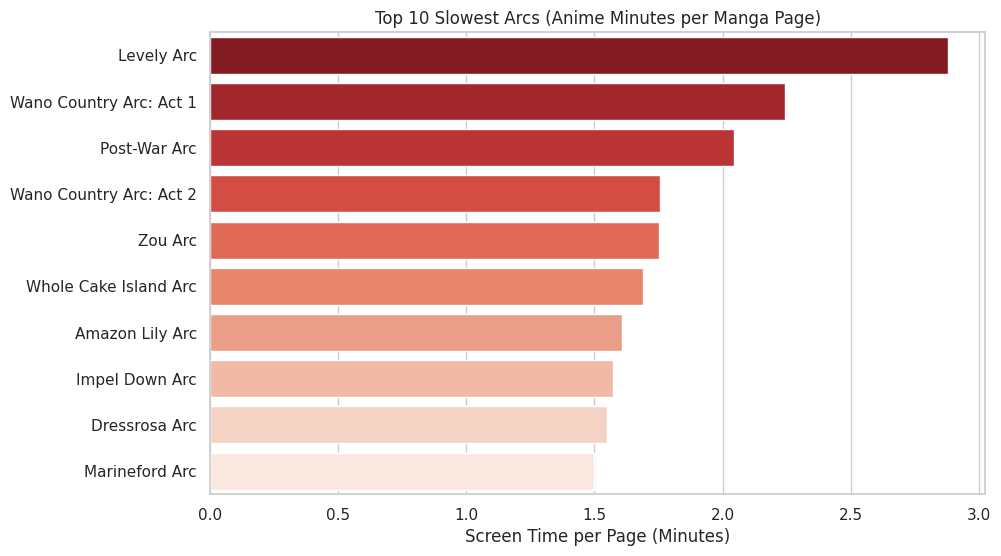

In [18]:
# Anime minutes divided by the total number of manga pages
canon['Minutes_per_Page'] = canon['TotalMinutes(avg 24)'] / canon['TotalPages']

print("--- Most Stretched Arcs (More screen time per manga page) ---")
display(
    canon.sort_values(by='Minutes_per_Page', ascending=False)[
        ['Arc', 'TotalMinutes(avg 24)', 'TotalPages', 'Minutes_per_Page']
    ].head(5)
)

# Visualizing the slowest arcs
plt.figure(figsize=(10, 6))
top_stretched = canon.sort_values(by='Minutes_per_Page', ascending=False).head(10)
sns.barplot(x='Minutes_per_Page', y='Arc', data=top_stretched, palette='Reds_r')
plt.title('Top 10 Slowest Arcs (Anime Minutes per Manga Page)')
plt.xlabel('Screen Time per Page (Minutes)')
plt.ylabel('')
plt.show()

## 8. Era Analysis: Pre-Timeskip vs. Post-Timeskip

The story of One Piece is clearly divided by a 2-year time skip (Timeskip), marking the beginning of the Return to Sabaody Arc (Chapter 598 in the manga and Episode 517 in the anime). Let’s split the dataset into these two major eras and analyze how adaptation pacing and filler quantity have changed.

--- Anime Pacing (Chapters per Episode) by Era ---


,Era,Pacing (Chapters/Episode)
0,Post-Timeskip,0.86
1,Pre-Timeskip,1.56



--- Percentage of Filler Episodes by Era ---


,Era,TotalEpisodes_Filler,Total_Episodes_Era,Filler_Rate (%)
0,Post-Timeskip,16,512,3.1
1,Pre-Timeskip,63,516,12.2


/tmp/ipykernel_10804/2889129521.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Era', y='Pacing (Chapters/Episode)', data=avg_pacing, palette='Blues', ax=axes[0])
/tmp/ipykernel_10804/2889129521.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Era', y='Filler_Rate (%)', data=filler_comparison, palette='Oranges', ax=axes[1])


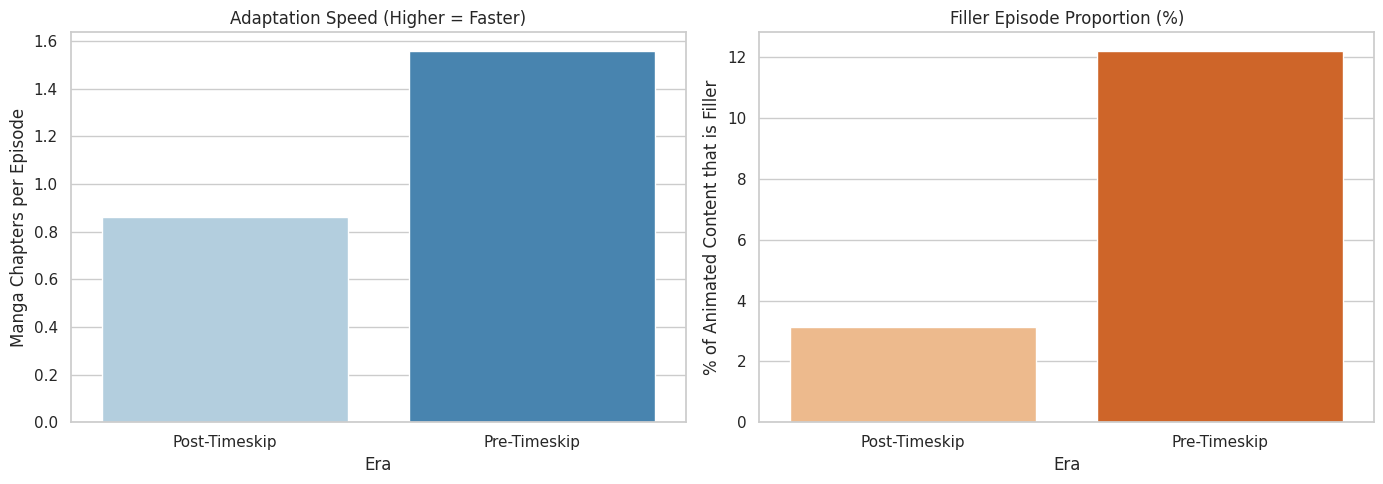

In [19]:
# Function to classify the Era based on the Return to Sabaody starting point
def define_era(chapter, episode):
    if chapter == 0:  # If it's a filler (0 chapters), check episode number
        return 'Pre-Timeskip' if episode < 517 else 'Post-Timeskip'
    else:  # If it's canonical, check chapter number
        return 'Pre-Timeskip' if chapter < 598 else 'Post-Timeskip'

# Creating the new 'Era' column
data['Era'] = data.apply(lambda row: define_era(row['Start onChapter'], row['Start onEpisode']), axis=1)

# 1. Comparing average pacing between eras
canon_era = data[data['TotalChapters'] > 0].copy()
canon_era['Pacing (Chapters/Episode)'] = canon_era['TotalChapters'] / canon_era['TotalEpisodes']
avg_pacing = canon_era.groupby('Era')['Pacing (Chapters/Episode)'].mean().reset_index()

print("--- Anime Pacing (Chapters per Episode) by Era ---")
display(avg_pacing.round(2))

# 2. Comparing filler production rate by era
fillers_era = data[data['TotalChapters'] == 0].groupby('Era')['TotalEpisodes'].sum().reset_index()
canon_episodes_era = canon_era.groupby('Era')['TotalEpisodes'].sum().reset_index()

# Merging tables
filler_comparison = pd.merge(fillers_era, canon_episodes_era, on='Era', suffixes=('_Filler', '_Canon'))
filler_comparison['Total_Episodes_Era'] = (
    filler_comparison['TotalEpisodes_Filler'] + filler_comparison['TotalEpisodes_Canon']
)
filler_comparison['Filler_Rate (%)'] = (
    filler_comparison['TotalEpisodes_Filler'] / filler_comparison['Total_Episodes_Era']
) * 100

print("\n--- Percentage of Filler Episodes by Era ---")
display(
    filler_comparison[['Era', 'TotalEpisodes_Filler', 'Total_Episodes_Era', 'Filler_Rate (%)']]
    .round(1)
)

# Comparative plots: Pacing vs Fillers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Era', y='Pacing (Chapters/Episode)', data=avg_pacing, palette='Blues', ax=axes[0])
axes[0].set_title('Adaptation Speed (Higher = Faster)')
axes[0].set_ylabel('Manga Chapters per Episode')

sns.barplot(x='Era', y='Filler_Rate (%)', data=filler_comparison, palette='Oranges', ax=axes[1])
axes[1].set_title('Filler Episode Proportion (%)')
axes[1].set_ylabel('% of Animated Content that is Filler')

plt.tight_layout()
plt.show()